# Analysis of the impact of diploidy

In [1]:
import os 
import json 
import matplotlib.pyplot as plt
import numpy as np
import sys

from base_fns import get_local_file
file = get_local_file()

local_dir = os.path.dirname(os.path.dirname(file))
sys.path.append(local_dir)


def add_env_switch_lines(config, generations, label='env switch'):
    """Trace une ligne verticale a chaque generation de changement d'env.
    Ne fait rien si 'switch' n'est pas dans le config (safe pour les expes a env fixe)."""
    if 'switch' not in config:
        return
    switch = config['switch']
    max_gen = int(np.max(generations))
    for j, g in enumerate(range(switch, max_gen + 1, switch)):
        plt.axvline(x=g, color='grey', linestyle='--', alpha=0.65,
                    label=label if j == 0 else None)
        
def load_dominance_csv(path, id_exp, type_genome) :
    """Lit le csv dominance_analysis et renvoie les generations et les pourcentages."""
    csv_dir = os.path.join(local_dir, 'results', '{}'.format(path), 'id_{}'.format(id_exp), type_genome, 'txt', 'dominance_analysis')
    generations = [] ; percents = []
    with open(csv_dir, 'r') as f : 
        lines = f.readlines()
    for line in lines[1:] :          # on saute l'en-tete
        line = line.strip()
        if not line : 
            continue
        gen, type_env, switched, ties, total, percent = line.split(',')
        generations.append(int(gen))
        percents.append(float(percent))
    return generations, percents

## How to use

Please change the direction of the results you want to analyze : 

In [2]:
# to change 
path = 'final7'
number = 1
# end of to change 

results_dir = os.path.join(local_dir, 'results', '{}'.format(path), 'id_{}'.format(number))
haploid_dir = os.path.join(results_dir, 'haploid')
diploid_dir = os.path.join(results_dir, 'diploid')
json_haploid_dir = os.path.join(haploid_dir, 'json')
json_diploid_dir = os.path.join(diploid_dir, 'json')
file = 'configs.json'
haploid_json_dir_file = os.path.join(json_haploid_dir, file)
diploid_json_dir_file = os.path.join(json_diploid_dir, file)
with open(haploid_json_dir_file, 'r') as f : 
    haploid_data_config = json.load(f)

result = ''
for key, value in haploid_data_config.items():
    result += f'{key} : {value}\n'

with open(diploid_json_dir_file, 'r') as f : 
    diploid_data_config = json.load(f)

diploid_result = ''
for key, value in diploid_data_config.items():
    diploid_result += f'{key} : {value}\n'

print(result)
print(diploid_result)

number_of_exp : 5
number_of_config : 1
threshold_var : 0.15
body_shape : [5, 5]
max_weight : 1
max_bias : 1
response : 1
max_weight_cppn : 20
max_bias_cppn : 20
range_weight : 1
range_bias : 1
sigma_weight : 0.1
sigma_bias : 0.1
sigma_dominance : 0.1
threshold_weight : 0.03
threshold_bias : 0.01
threshold_function : 0.01
threshold_dominance : 0.07
switch : 20
generations : 600
population : 128
number_of_winner : 1
number_in_tournament : 2
number_of_elites : 1
shape_of_cppn : [[11], [5], [3, 3], [1, 1]]
function_pool : ['gaussian', 'sin', 'tanh']
n_steps : [1000, 500]
number_of_reported_individuals : 40
cpus : 28
env_name : ['Pusher-v0', 'Walker-v0']

number_of_exp : 5
number_of_config : 1
threshold_var : 0.15
body_shape : [5, 5]
max_weight : 1
max_bias : 1
response : 1
max_weight_cppn : 20
max_bias_cppn : 20
range_weight : 1
range_bias : 1
sigma_weight : 0.1
sigma_bias : 0.1
sigma_dominance : 0.1
threshold_weight : 0.03
threshold_bias : 0.01
threshold_function : 0.01
threshold_dominanc

In [3]:
general_percents_haploid = []
general_percents_diploid = []

for k in range(haploid_data_config['number_of_config']) : 
    general_percents_haploid_sigma = []
    general_percents_diploid_sigma = []
    for i in range(diploid_data_config['number_of_exp']) :
        id_exp = number + k * diploid_data_config['number_of_exp'] + i

        generations, percents = load_dominance_csv(path, id_exp, 'haploid')
        general_percents_haploid_sigma.append(percents)

        generations, percents = load_dominance_csv(path, id_exp, 'diploid')
        general_percents_diploid_sigma.append(percents)

    general_percents_haploid.append(general_percents_haploid_sigma)
    general_percents_diploid.append(general_percents_diploid_sigma)

generations = np.array(generations)
general_percents_haploid = np.array(general_percents_haploid)
general_percents_diploid = np.array(general_percents_diploid)

print('{} config, {} exp par config, {} generations'.format(*general_percents_diploid.shape))

1 config, 5 exp par config, 600 generations


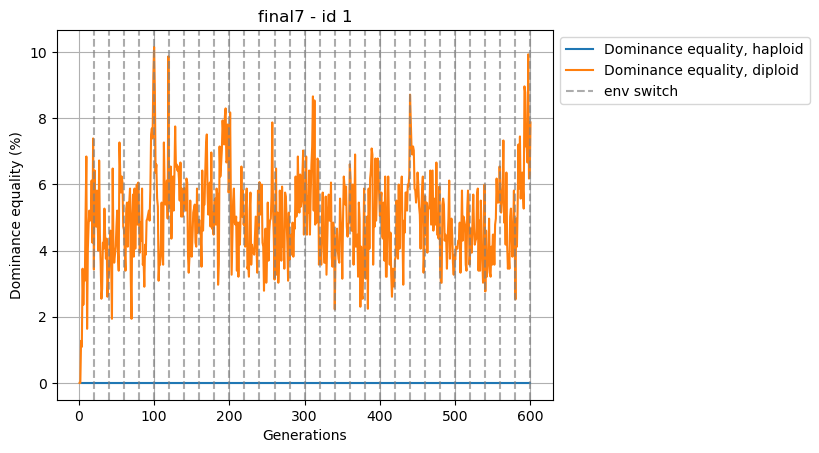

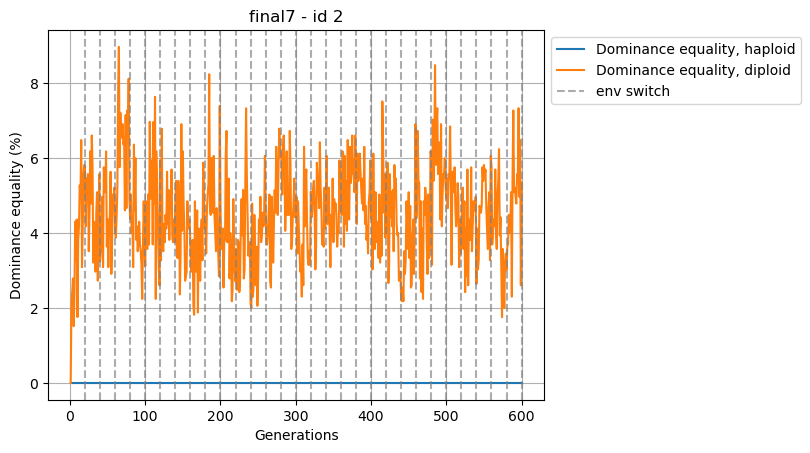

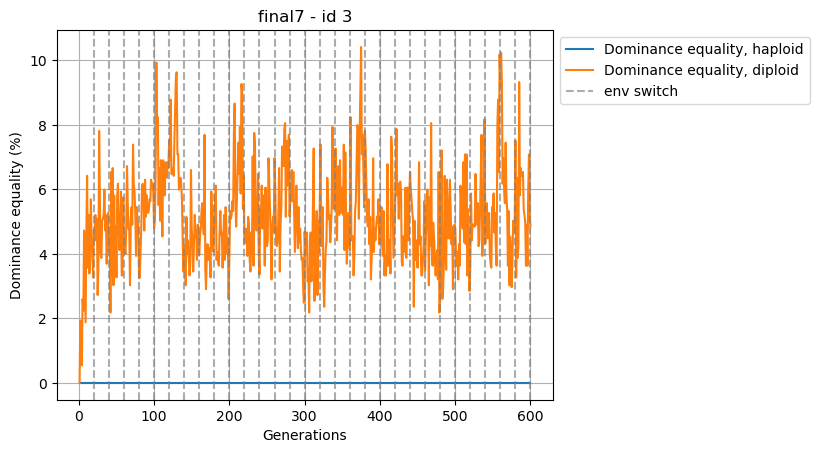

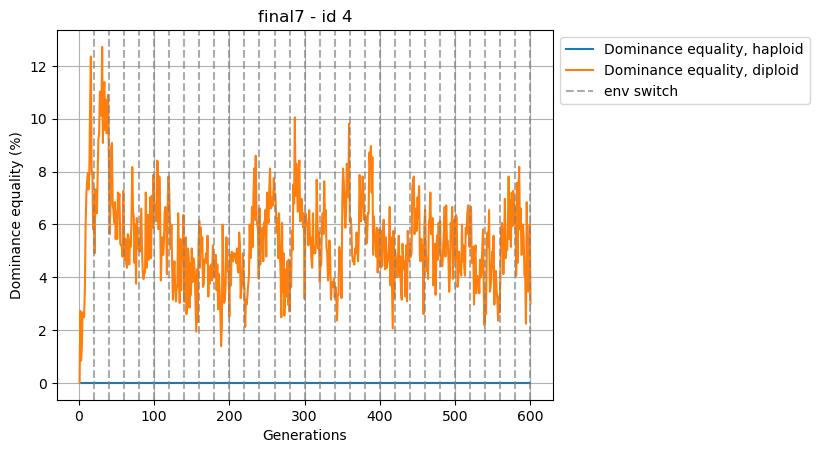

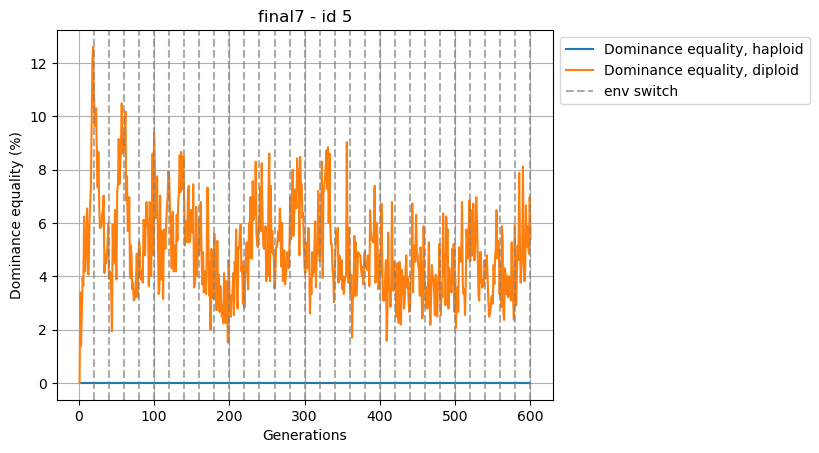

In [4]:
for k in range(haploid_data_config['number_of_config']) :
    for i in range(diploid_data_config['number_of_exp']) :
        id_exp = number + k * diploid_data_config['number_of_exp'] + i

        plt.figure()
        plt.title('{} - id {}'.format(path, id_exp))

        plt.plot(generations, general_percents_haploid[k][i], label = 'Dominance equality, haploid')
        plt.plot(generations, general_percents_diploid[k][i], label = 'Dominance equality, diploid')
        plt.xlabel('Generations')
        plt.ylabel('Dominance equality (%)')
        plt.grid(True, which = 'both')
        add_env_switch_lines(haploid_data_config, generations)
        plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
        plt.show()

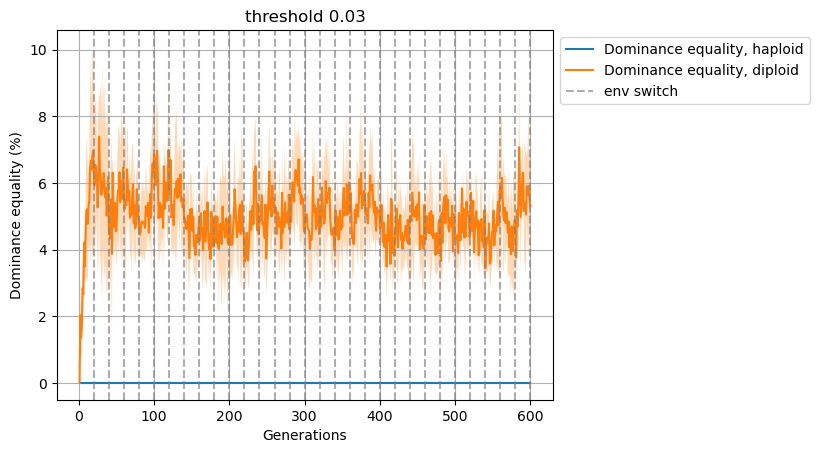

In [5]:
for i in range(haploid_data_config['number_of_config']) :
    threshold = haploid_data_config['threshold_weight'] + i * haploid_data_config['threshold_var']

    mean_haploid = np.mean(general_percents_haploid[i], axis = 0)
    mean_diploid = np.mean(general_percents_diploid[i], axis = 0)
    std_haploid = np.std(general_percents_haploid[i], axis = 0)
    std_diploid = np.std(general_percents_diploid[i], axis = 0)

    plt.figure()
    plt.title('threshold {:.2f}'.format(threshold))

    plt.plot(generations, mean_haploid, label = 'Dominance equality, haploid')
    plt.fill_between(generations, mean_haploid - std_haploid, mean_haploid + std_haploid, alpha = 0.3)
    plt.plot(generations, mean_diploid, label = 'Dominance equality, diploid')
    plt.fill_between(generations, mean_diploid - std_diploid, mean_diploid + std_diploid, alpha = 0.3)
    plt.xlabel('Generations')
    plt.ylabel('Dominance equality (%)')
    plt.grid(True, which = 'both')
    add_env_switch_lines(haploid_data_config, generations)
    plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
    plt.show()

In [6]:
for i in range(haploid_data_config['number_of_config']) :
    threshold = haploid_data_config['threshold_weight'] + i * haploid_data_config['threshold_var']

    hap = general_percents_haploid[i]
    dip = general_percents_diploid[i]

    print('----- threshold {:.2f} -----'.format(threshold))
    print('haploid : mean {:.3f} %, std {:.3f}, max {:.3f} %'.format(hap.mean(), hap.std(), hap.max()))
    print('diploid : mean {:.3f} %, std {:.3f}, max {:.3f} %'.format(dip.mean(), dip.std(), dip.max()))
    print()

----- threshold 0.03 -----
haploid : mean 0.000 %, std 0.000, max 0.000 %
diploid : mean 4.992 %, std 1.542, max 12.720 %



## Invalid individuals (%)

In [7]:
def load_invalid_csv(path, id_exp, type_genome, population) :
    """Lit le csv invalid_analysis et renvoie les generations et le % d'individus invalides."""
    csv_dir = os.path.join(local_dir, 'results', '{}'.format(path), 'id_{}'.format(id_exp), type_genome, 'txt', 'invalid_analysis')
    generations = [] ; percents = []
    with open(csv_dir, 'r') as f :
        lines = f.readlines()
    for line in lines[1:] :          # on saute l'en-tete
        line = line.strip()
        if not line :
            continue
        gen, type_genome_csv, type_env, invalid = line.split(',')
        generations.append(int(gen))
        percents.append(float(invalid) / population * 100)
    return generations, percents

In [8]:
population = haploid_data_config['population']

general_invalid_haploid = []
general_invalid_diploid = []

for k in range(haploid_data_config['number_of_config']) :
    general_invalid_haploid_sigma = []
    general_invalid_diploid_sigma = []
    for i in range(diploid_data_config['number_of_exp']) :
        id_exp = number + k * diploid_data_config['number_of_exp'] + i

        generations, percents = load_invalid_csv(path, id_exp, 'haploid', population)
        general_invalid_haploid_sigma.append(percents)

        generations, percents = load_invalid_csv(path, id_exp, 'diploid', population)
        general_invalid_diploid_sigma.append(percents)

    general_invalid_haploid.append(general_invalid_haploid_sigma)
    general_invalid_diploid.append(general_invalid_diploid_sigma)

generations = np.array(generations)
general_invalid_haploid = np.array(general_invalid_haploid)
general_invalid_diploid = np.array(general_invalid_diploid)

print('{} config, {} exp par config, {} generations'.format(*general_invalid_diploid.shape))

1 config, 5 exp par config, 600 generations


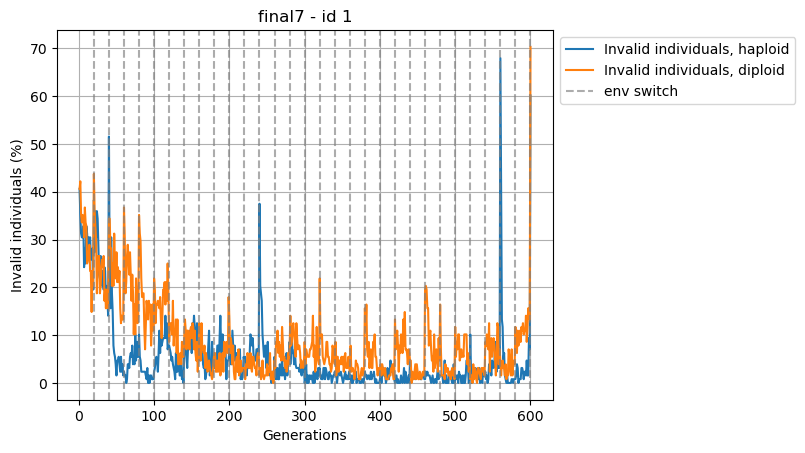

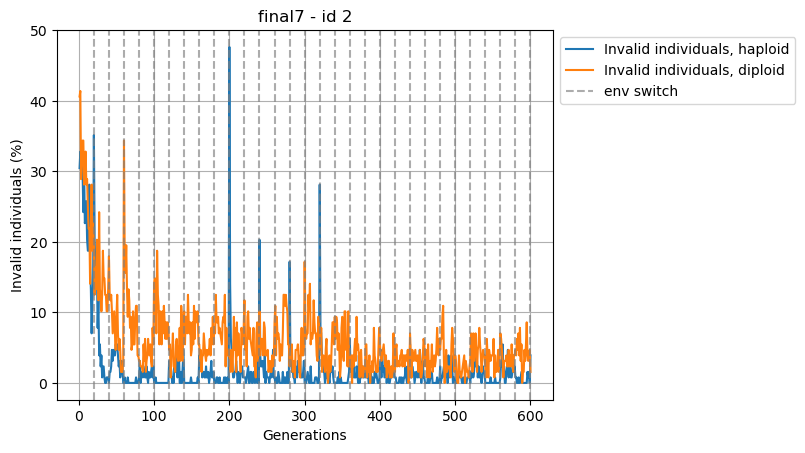

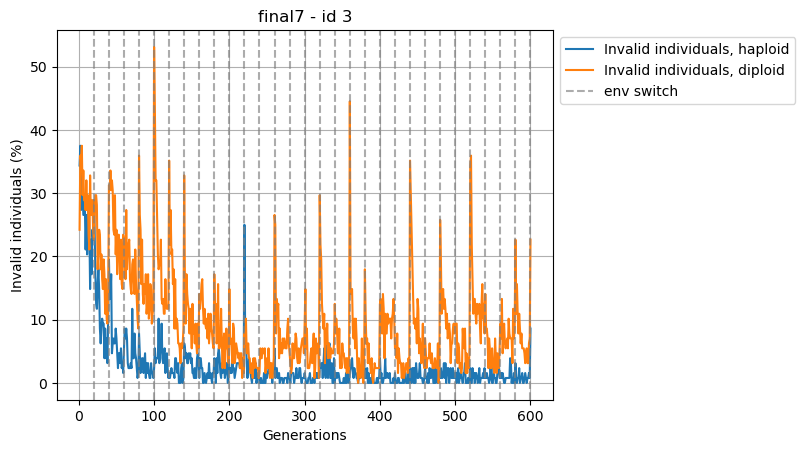

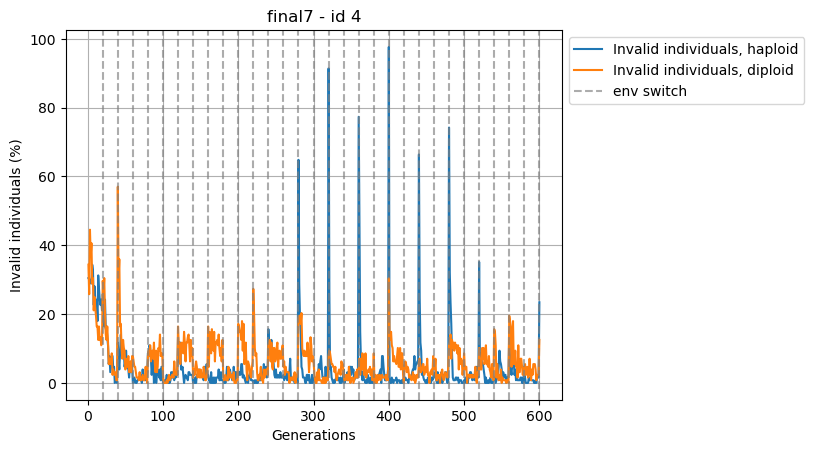

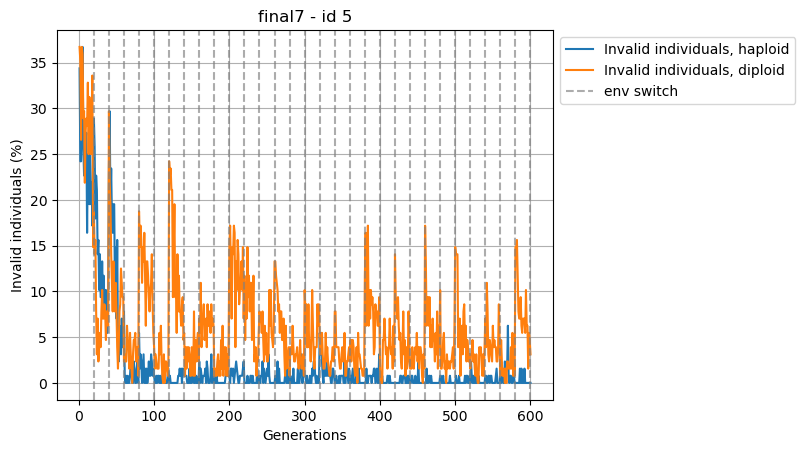

In [9]:
for k in range(haploid_data_config['number_of_config']) :
    for i in range(diploid_data_config['number_of_exp']) :
        id_exp = number + k * diploid_data_config['number_of_exp'] + i

        plt.figure()
        plt.title('{} - id {}'.format(path, id_exp))

        plt.plot(generations, general_invalid_haploid[k][i], label = 'Invalid individuals, haploid')
        plt.plot(generations, general_invalid_diploid[k][i], label = 'Invalid individuals, diploid')
        plt.xlabel('Generations')
        plt.ylabel('Invalid individuals (%)')
        plt.grid(True, which = 'both')
        add_env_switch_lines(haploid_data_config, generations)
        plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
        plt.show()

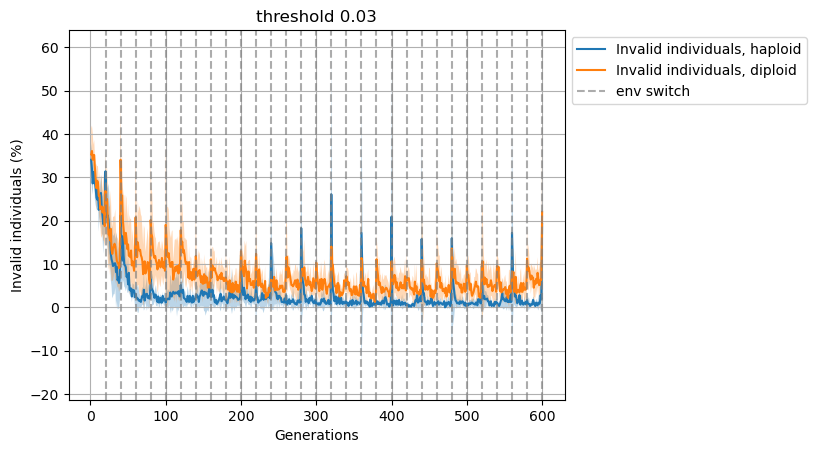

In [10]:
for i in range(haploid_data_config['number_of_config']) :
    threshold = haploid_data_config['threshold_weight'] + i * haploid_data_config['threshold_var']

    mean_haploid = np.mean(general_invalid_haploid[i], axis = 0)
    mean_diploid = np.mean(general_invalid_diploid[i], axis = 0)
    std_haploid = np.std(general_invalid_haploid[i], axis = 0)
    std_diploid = np.std(general_invalid_diploid[i], axis = 0)

    plt.figure()
    plt.title('threshold {:.2f}'.format(threshold))

    plt.plot(generations, mean_haploid, label = 'Invalid individuals, haploid')
    plt.fill_between(generations, mean_haploid - std_haploid, mean_haploid + std_haploid, alpha = 0.3)
    plt.plot(generations, mean_diploid, label = 'Invalid individuals, diploid')
    plt.fill_between(generations, mean_diploid - std_diploid, mean_diploid + std_diploid, alpha = 0.3)
    plt.xlabel('Generations')
    plt.ylabel('Invalid individuals (%)')
    plt.grid(True, which = 'both')
    add_env_switch_lines(haploid_data_config, generations)
    plt.legend(bbox_to_anchor=(1,1), loc = 'upper left')
    plt.show()

In [11]:
for i in range(haploid_data_config['number_of_config']) :
    threshold = haploid_data_config['threshold_weight'] + i * haploid_data_config['threshold_var']

    hap = general_invalid_haploid[i]
    dip = general_invalid_diploid[i]

    print('----- threshold {:.2f} -----'.format(threshold))
    print('haploid : mean {:.3f} %, std {:.3f}, max {:.3f} %'.format(hap.mean(), hap.std(), hap.max()))
    print('diploid : mean {:.3f} %, std {:.3f}, max {:.3f} %'.format(dip.mean(), dip.std(), dip.max()))
    print()

----- threshold 0.03 -----
haploid : mean 3.453 %, std 7.199, max 97.656 %
diploid : mean 7.598 %, std 7.349, max 70.312 %

